# Paper [IFAC]: Human Failure Analyses

For the paper `Irshad, L., & Hulse, D. (2022). Can Resilience Assessments Inform Early Design Human Factors Decision-making?. IFAC-PapersOnLine, 55(29), 61-66.`

```
Copyright © 2024, United States Government, as represented by the Administrator of the National Aeronautics and Space Administration. All rights reserved.

The “"Fault Model Design tools - fmdtools version 2"” software is licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. 

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.
```


In [13]:
from fmdtools.sim.sample import ParameterDomain, ParameterSample, FaultDomain, FaultSample
import fmdtools.analyze as an
import fmdtools.sim.propagate as prop
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42
import multiprocessing as mp
import scipy.stats as stats


import multiprocessing as mp

In [14]:
from fmdtools_examples.navigating_rover.model_human import RoverHuman, RoverHumanParam, asg_pos
from fmdtools_examples.navigating_rover.model_main import plot_map

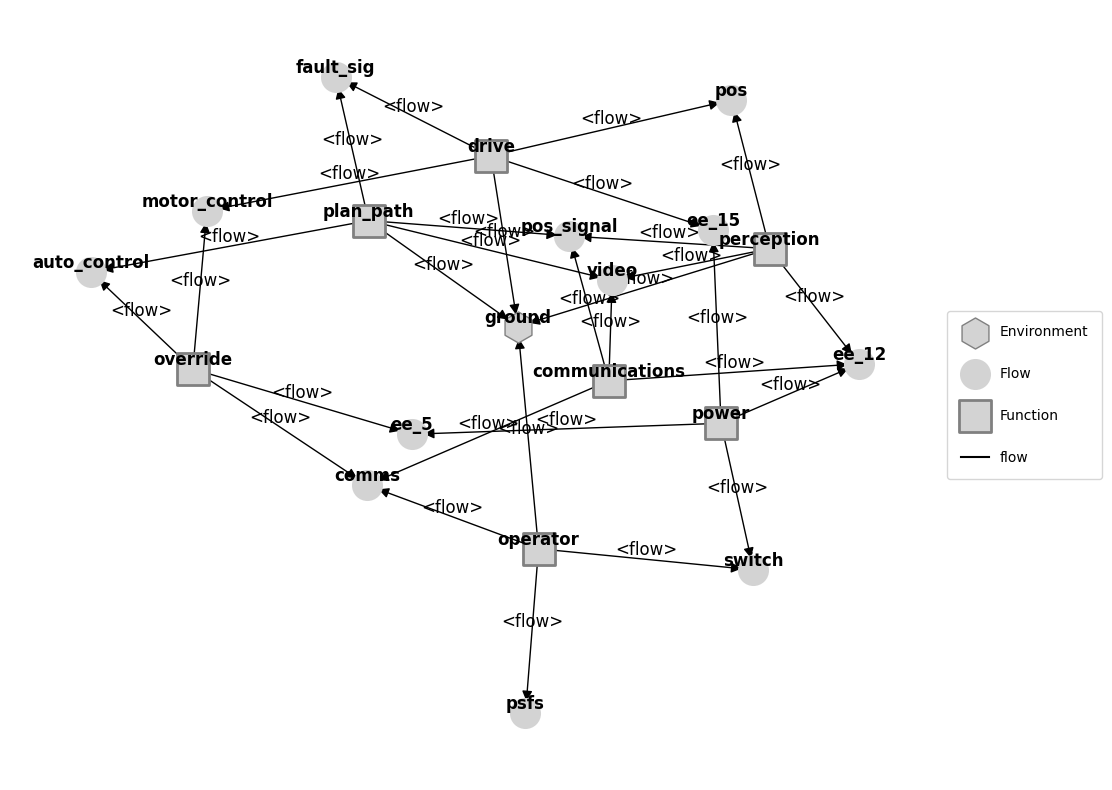

In [15]:
mdl = RoverHuman()
g = mdl.as_modelgraph()
fig, ax = g.draw()

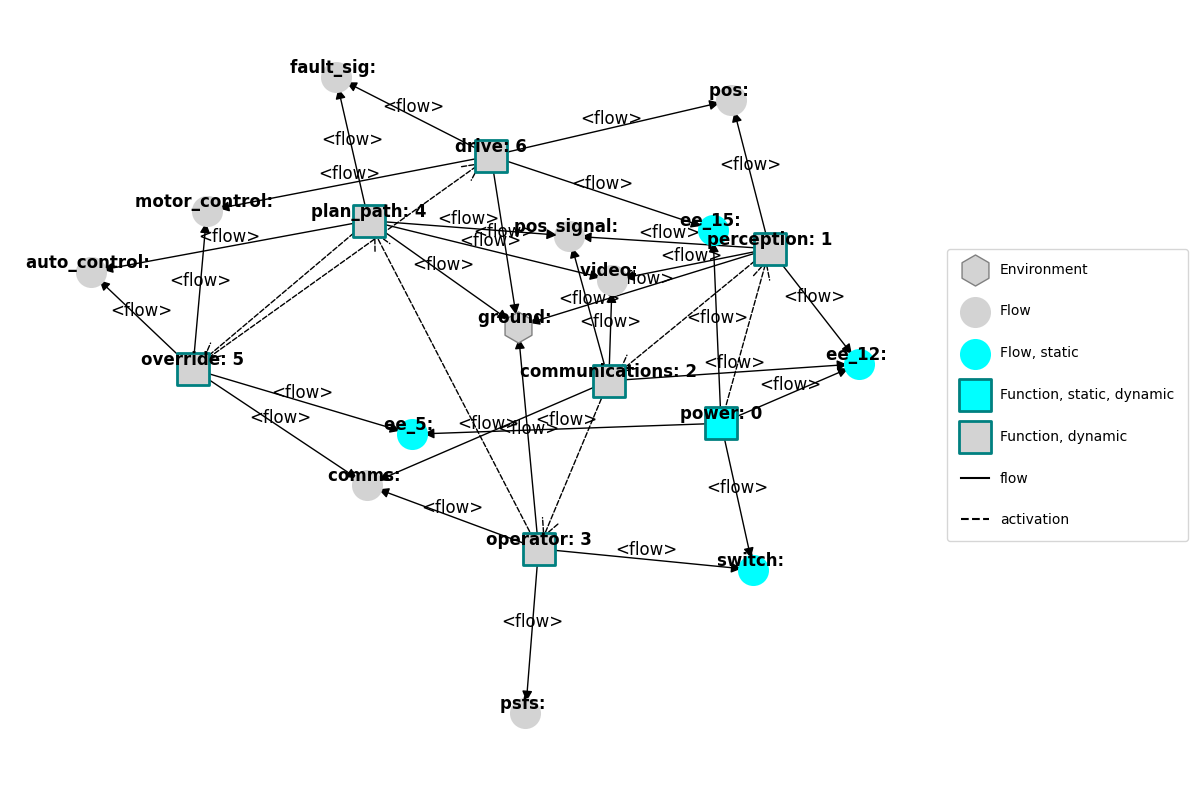

In [16]:
g.set_exec_order(mdl)
fig, ax = g.draw()

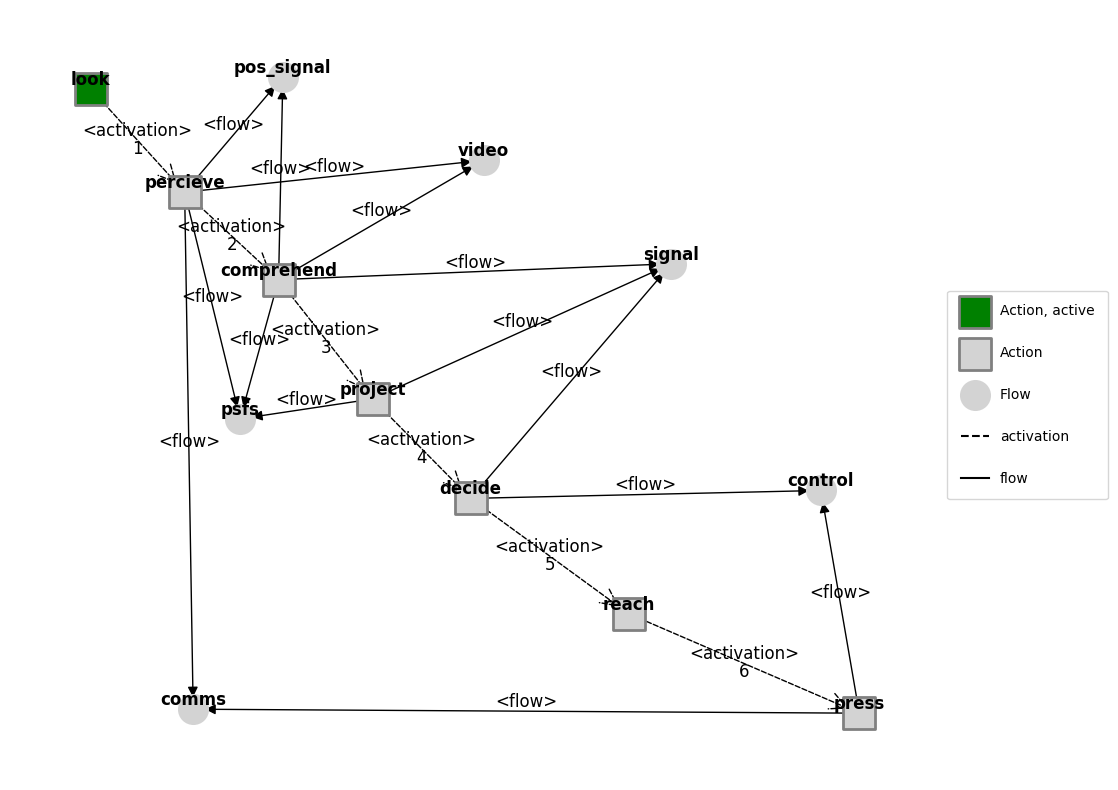

In [17]:
ag = mdl.fxns['operator'].aa.as_modelgraph()
ag.set_pos(**asg_pos)
fig, ax = ag.draw()

In [18]:
fig.savefig("outputs_paper_ifac_human/action_graph.pdf", format="pdf", bbox_inches = 'tight', pad_inches = 0)

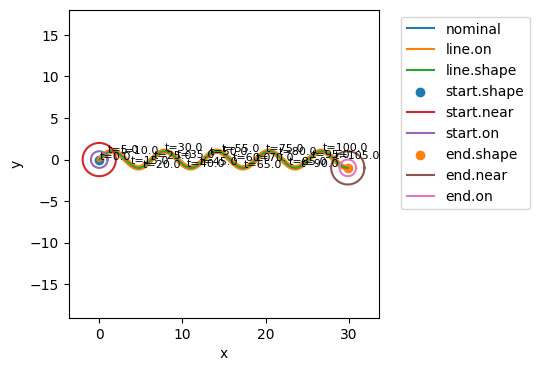

In [19]:
mdl = RoverHuman(p={'linetype': 'sine', 'period': 10, 'amp': 3, 'drive_modes': {'mode_options':'manual'}})
er, hist = prop.nominal(mdl)
fig, ax = plot_map(mdl, hist)

In [20]:
mdl.fxns['drive'].m

DriveMode(faults=set(), sub_faults=False, fault_stuck={'disturbances': (('s.friction', 10.0),)}, fault_stuck_right={'disturbances': (('s.friction', 3.0), ('s.drift', 0.2))}, fault_stuck_left={'disturbances': (('s.friction', 3.0), ('s.drift', -0.2))}, fault_custom={})

In [21]:
fd_hum = FaultDomain(mdl)
fd_hum.add_all_fxn_modes('operator')
fd_hum

FaultDomain with faults:
 -('roverhuman.fxns.operator.aa.acts.look', 'failed_no_action')
 -('roverhuman.fxns.operator.aa.acts.percieve', 'failed_no_action')
 -('roverhuman.fxns.operator.aa.acts.percieve', 'not_visible')
 -('roverhuman.fxns.operator.aa.acts.percieve', 'wrong_position')
 -('roverhuman.fxns.operator.aa.acts.comprehend', 'failed_no_action')
 -('roverhuman.fxns.operator.aa.acts.project', 'failed_fast')
 -('roverhuman.fxns.operator.aa.acts.project', 'failed_no_action')
 -('roverhuman.fxns.operator.aa.acts.project', 'failed_slow')
 -('roverhuman.fxns.operator.aa.acts.project', 'failed_turn_left')
 -('roverhuman.fxns.operator.aa.acts.project', 'failed_turn_right')
 -...more

In [22]:
fs_hum = FaultSample(fd_hum)
fs_hum.add_fault_phases("start")
fs_hum

FaultSample of scenarios: 
 - roverhuman_fxns_operator_aa_acts_look_failed_no_action_t15p0
 - roverhuman_fxns_operator_aa_acts_percieve_failed_no_action_t15p0
 - roverhuman_fxns_operator_aa_acts_percieve_not_visible_t15p0
 - roverhuman_fxns_operator_aa_acts_percieve_wrong_position_t15p0
 - roverhuman_fxns_operator_aa_acts_comprehend_failed_no_action_t15p0
 - roverhuman_fxns_operator_aa_acts_project_failed_fast_t15p0
 - roverhuman_fxns_operator_aa_acts_project_failed_no_action_t15p0
 - roverhuman_fxns_operator_aa_acts_project_failed_slow_t15p0
 - roverhuman_fxns_operator_aa_acts_project_failed_turn_left_t15p0
 - roverhuman_fxns_operator_aa_acts_project_failed_turn_right_t15p0
 - ... (19 total)

In [23]:
fs_hum.scenarios()

[SingleFaultScenario(sequence={15.0: Injection(faults={'roverhuman.fxns.operator.aa.acts.look': ['failed_no_action']}, disturbances={})}, times=(np.float64(15.0),), function='roverhuman.fxns.operator.aa.acts.look', fault='failed_no_action', rate=np.float64(1.0), name='roverhuman_fxns_operator_aa_acts_look_failed_no_action_t15p0', time=np.float64(15.0), phase='start'),
 SingleFaultScenario(sequence={15.0: Injection(faults={'roverhuman.fxns.operator.aa.acts.percieve': ['failed_no_action']}, disturbances={})}, times=(np.float64(15.0),), function='roverhuman.fxns.operator.aa.acts.percieve', fault='failed_no_action', rate=np.float64(1.0), name='roverhuman_fxns_operator_aa_acts_percieve_failed_no_action_t15p0', time=np.float64(15.0), phase='start'),
 SingleFaultScenario(sequence={15.0: Injection(faults={'roverhuman.fxns.operator.aa.acts.percieve': ['not_visible']}, disturbances={})}, times=(np.float64(15.0),), function='roverhuman.fxns.operator.aa.acts.percieve', fault='not_visible', rate=np

In [24]:
ecs, hists = prop.fault_sample(mdl, fs_hum)

SCENARIOS COMPLETE: 100%|██████████| 19/19 [00:06<00:00,  3.09it/s]


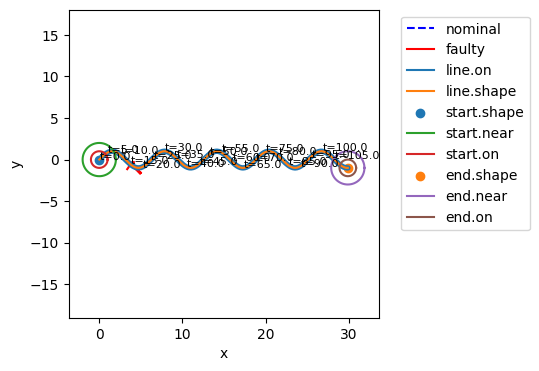

In [25]:
fig, ax = plot_map(mdl, hists)

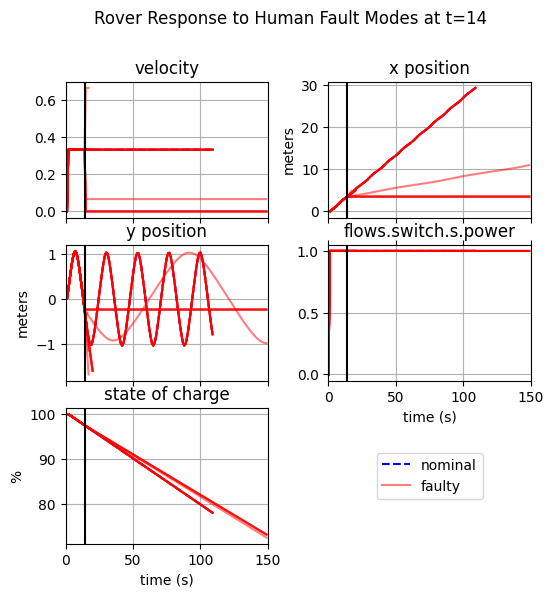

In [26]:
figs, axs = hists.plot_line('flows.pos.s.vel','flows.pos.s.x', 'flows.pos.s.y',
                            'flows.switch.s.power', 'fxns.power.s.charge', time_slice=[14],
                            title="Rover Response to Human Fault Modes at t=14",
                            indiv_kwargs={'faulty':{'alpha':0.5, 'color':'red'}},
                            ylabels={'flows.pos.s.x':'meters','flows.pos.s.y':'meters', 'flows.ground.s.x':'m/s',
                                   'fxns.power.s.charge': '%'}, xlabel='time (s)',
                            titles={'flows.pos.s.x':'x position','flows.pos.s.y':'y position', 'flows.pos.s.vel':'velocity',
                                   'flows.s.switch': 'on/off switch', 'fxns.power.s.charge': 'state of charge'}, h_padding=0.3)

In [27]:
fig.savefig("outputs_paper_ifac_human/rover_fault_behavior.pdf", format="pdf", bbox_inches = 'tight', pad_inches = 0)

In [28]:
from fmdtools_examples.navigating_rover.model_degradation import PSFDegradationShort, PSFShortParams

In [29]:
pd_deg = ParameterDomain(PSFShortParams)
pd_deg.add_constant('stress_param', 0.0)
pd_deg.add_variable('experience', var_lim=(1.0, 5.0))
pd_deg(2,2)

PSFShortParams(experience=2.0, stress_param=0.0, fatigue_param=1.0)

In [30]:
ps_deg = ParameterSample(pd_deg)
ps_deg.add_variable_ranges(replicates = 10)
ps_deg.scenarios()

[ParameterScenario(sequence={}, times=(), p={'experience': np.float64(1.0), 'stress_param': 0.0}, r={'seed': np.uint32(724269981)}, sp={}, prob=0.02, inputparams={0: np.float64(1.0)}, rangeid='', name='rep0_range_0'),
 ParameterScenario(sequence={}, times=(), p={'experience': np.float64(1.0), 'stress_param': 0.0}, r={'seed': np.uint32(3105616893)}, sp={}, prob=0.02, inputparams={0: np.float64(1.0)}, rangeid='', name='rep1_range_1'),
 ParameterScenario(sequence={}, times=(), p={'experience': np.float64(1.0), 'stress_param': 0.0}, r={'seed': np.uint32(2833239588)}, sp={}, prob=0.02, inputparams={0: np.float64(1.0)}, rangeid='', name='rep2_range_2'),
 ParameterScenario(sequence={}, times=(), p={'experience': np.float64(1.0), 'stress_param': 0.0}, r={'seed': np.uint32(2767900790)}, sp={}, prob=0.02, inputparams={0: np.float64(1.0)}, rangeid='', name='rep3_range_3'),
 ParameterScenario(sequence={}, times=(), p={'experience': np.float64(1.0), 'stress_param': 0.0}, r={'seed': np.uint32(592103

In [31]:
deg_mdl = PSFDegradationShort()
ec_psf_short, hist_psf_short = prop.parameter_sample(deg_mdl, ps_deg, run_stochastic=True)

SCENARIOS COMPLETE: 100%|██████████| 50/50 [00:00<00:00, 602.28it/s]


In [32]:
hist_psf_short.keys()

dict_keys(['rep0_range_0.s.fatigue', 'rep0_range_0.s.stress', 'rep0_range_0.s.experience', 'rep0_range_0.r.s.fatigue_param', 'rep0_range_0.r.probdens', 'rep0_range_0.time', 'rep1_range_1.s.fatigue', 'rep1_range_1.s.stress', 'rep1_range_1.s.experience', 'rep1_range_1.r.s.fatigue_param', 'rep1_range_1.r.probdens', 'rep1_range_1.time', 'rep2_range_2.s.fatigue', 'rep2_range_2.s.stress', 'rep2_range_2.s.experience', 'rep2_range_2.r.s.fatigue_param', 'rep2_range_2.r.probdens', 'rep2_range_2.time', 'rep3_range_3.s.fatigue', 'rep3_range_3.s.stress', 'rep3_range_3.s.experience', 'rep3_range_3.r.s.fatigue_param', 'rep3_range_3.r.probdens', 'rep3_range_3.time', 'rep4_range_4.s.fatigue', 'rep4_range_4.s.stress', 'rep4_range_4.s.experience', 'rep4_range_4.r.s.fatigue_param', 'rep4_range_4.r.probdens', 'rep4_range_4.time', 'rep5_range_5.s.fatigue', 'rep5_range_5.s.stress', 'rep5_range_5.s.experience', 'rep5_range_5.r.s.fatigue_param', 'rep5_range_5.r.probdens', 'rep5_range_5.time', 'rep6_range_6.s.f

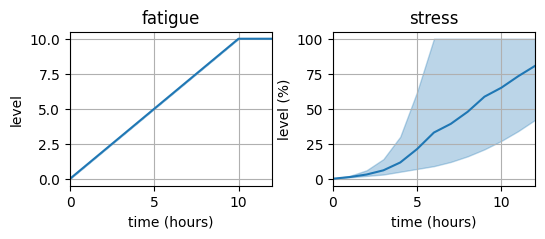

In [33]:
fig, axs = hist_psf_short.plot_line('s.fatigue', 's.stress', aggregation='mean_bound', xlabel="time (hours)",
                           ylabels={'s.fatigue': 'level','s.stress': 'level (%)'}, h_padding=0.3,
                           titles={'s.fatigue': 'fatigue', 's.stress': 'stress'})

In [34]:
fig.savefig("outputs_paper_ifac_human/degraded_PSFs.pdf", format="pdf", bbox_inches = 'tight', pad_inches = 0)

In [35]:
RoverHumanParam().psfs

PSFParam(fatigue=0.0, stress=0.0)

In [36]:
from fmdtools.sim.sample import ParameterHistSample
pd_psf = ParameterDomain(RoverHumanParam)
pd_psf.add_variables('psfs.fatigue', 'psfs.stress')
phs = ParameterHistSample(hist_psf_short, 's.fatigue', 's.stress', paramdomain=pd_psf)
# phs.add_hist_times('default', 1, ts=(0, 10, 1))
phs.add_hist_groups(ts=(0, 10, 1), reps=5)
# phs.add_hist_scenario(rep=4, t=1)
len(phs.scenarios())

50

In [37]:
ec_hum, hist_hum = prop.parameter_sample(mdl, phs)

SCENARIOS COMPLETE: 100%|██████████| 50/50 [00:25<00:00,  1.94it/s]


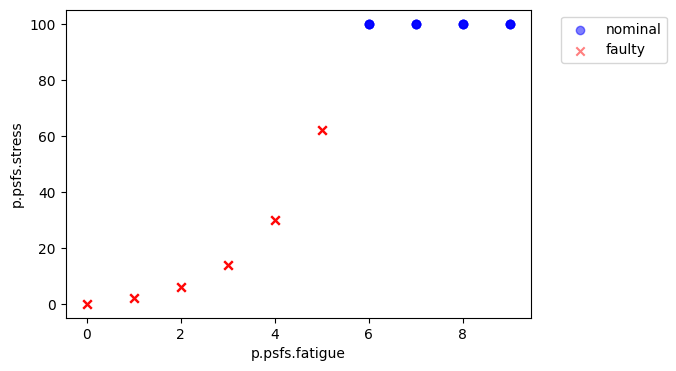

In [38]:
from fmdtools.analyze.tabulate import NominalEnvelope
na = NominalEnvelope(phs, ec_hum, 'at_finish', 'p.psfs.fatigue', 'p.psfs.stress')
fig, ax = na.as_plot()

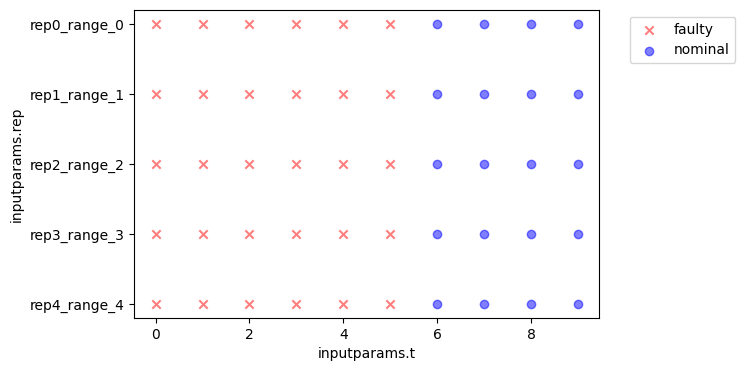

In [39]:
na = NominalEnvelope(phs, ec_hum, 'at_finish', 'inputparams.t', 'inputparams.rep')
fig, ax = na.as_plot()

In [40]:
fig.savefig("outputs_paper_ifac_human/nominal_PSF_completions.pdf", format="pdf", bbox_inches = 'tight', pad_inches = 0)

In [41]:
from fmdtools.sim.sample import SampleApproach
sa = SampleApproach(mdl)
sa.add_faultdomains(**{'drive': (('all_fxn_modes', 'drive'), {})})
sa.add_faultsamples(**{'drive': (('fault_phases', 'drive', 'start'), {})})
sa.scenarios()

[SingleFaultScenario(sequence={15.0: Injection(faults={'roverhuman.fxns.drive': ['custom']}, disturbances={})}, times=(np.float64(15.0),), function='roverhuman.fxns.drive', fault='custom', rate=np.float64(1.0), name='roverhuman_fxns_drive_custom_t15p0', time=np.float64(15.0), phase='start'),
 SingleFaultScenario(sequence={15.0: Injection(faults={'roverhuman.fxns.drive': ['elec_open']}, disturbances={})}, times=(np.float64(15.0),), function='roverhuman.fxns.drive', fault='elec_open', rate=np.float64(1.0), name='roverhuman_fxns_drive_elec_open_t15p0', time=np.float64(15.0), phase='start'),
 SingleFaultScenario(sequence={15.0: Injection(faults={'roverhuman.fxns.drive': ['stuck']}, disturbances={})}, times=(np.float64(15.0),), function='roverhuman.fxns.drive', fault='stuck', rate=np.float64(1.0), name='roverhuman_fxns_drive_stuck_t15p0', time=np.float64(15.0), phase='start'),
 SingleFaultScenario(sequence={15.0: Injection(faults={'roverhuman.fxns.drive': ['stuck_left']}, disturbances={})},

In [42]:
f_ecs, f_hists, apps = prop.nested_sample(mdl, phs,
                                          faultdomains={'drive': (('all_fxn_modes', 'drive'), {})},
                                          faultsamples={'drive': (('fault_phases', 'drive', 'start'), {})})

SCENARIOS COMPLETE:  12%|█▏        | 6/50 [00:16<02:01,  2.75s/it]C:\Users\dhulse\Documents\GitHub\fmdtools\src\fmdtools\sim\propagate.py:688: UserWarning: Faults found during the nominal run {'comprehend.failed_no_action': Fault(prob=1.0, cost=0.0, phases=(), disturbances=(), units='sim')}
  warnings.warn("Faults found during the nominal run " + str(endfaults))
SCENARIOS COMPLETE:  18%|█▊        | 9/50 [00:29<02:39,  3.90s/it]C:\Users\dhulse\Documents\GitHub\fmdtools\src\fmdtools\sim\propagate.py:688: UserWarning: Faults found during the nominal run {'percieve.failed_no_action': Fault(prob=1.0, cost=0.0, phases=(), disturbances=(), units='sim')}
  warnings.warn("Faults found during the nominal run " + str(endfaults))
SCENARIOS COMPLETE: 100%|██████████| 50/50 [02:53<00:00,  3.47s/it]


In [43]:
apps['hist_0'].get_scen_groups()

{(): ['roverhuman_fxns_drive_custom_t15p0',
  'roverhuman_fxns_drive_elec_open_t15p0',
  'roverhuman_fxns_drive_stuck_t15p0',
  'roverhuman_fxns_drive_stuck_left_t15p0',
  'roverhuman_fxns_drive_stuck_right_t15p0']}

In [44]:
apps['hist_2'].faultsamples['drive'].scenarios()

[SingleFaultScenario(sequence={15.0: Injection(faults={'roverhuman.fxns.drive': ['custom']}, disturbances={})}, times=(np.float64(15.0),), function='roverhuman.fxns.drive', fault='custom', rate=np.float64(1.0), name='roverhuman_fxns_drive_custom_t15p0', time=np.float64(15.0), phase='start'),
 SingleFaultScenario(sequence={15.0: Injection(faults={'roverhuman.fxns.drive': ['elec_open']}, disturbances={})}, times=(np.float64(15.0),), function='roverhuman.fxns.drive', fault='elec_open', rate=np.float64(1.0), name='roverhuman_fxns_drive_elec_open_t15p0', time=np.float64(15.0), phase='start'),
 SingleFaultScenario(sequence={15.0: Injection(faults={'roverhuman.fxns.drive': ['stuck']}, disturbances={})}, times=(np.float64(15.0),), function='roverhuman.fxns.drive', fault='stuck', rate=np.float64(1.0), name='roverhuman_fxns_drive_stuck_t15p0', time=np.float64(15.0), phase='start'),
 SingleFaultScenario(sequence={15.0: Injection(faults={'roverhuman.fxns.drive': ['stuck_left']}, disturbances={})},

In [45]:
from fmdtools.analyze.tabulate import NestedComparison
nc = NestedComparison(f_ecs, phs, ['inputparams.t'], apps, ['fault'], metrics=['end_dist', 'tot_deviation'])
nc.sort_by_factor('fault')
nc.sort_by_factor('inputparams.t')
nc.as_table()

,,end_dist,tot_deviation
1,stuck_left,24.035598,0.310888
0,stuck_left,24.035598,0.310888
2,stuck_left,24.035598,0.310888
5,stuck_left,24.035598,0.310888
4,stuck_left,24.035598,0.310888
3,stuck_left,24.035598,0.310888
4,stuck_right,24.415309,0.216505
0,stuck_right,24.415309,0.216505
2,stuck_right,24.415309,0.216505
1,stuck_right,24.415309,0.216505


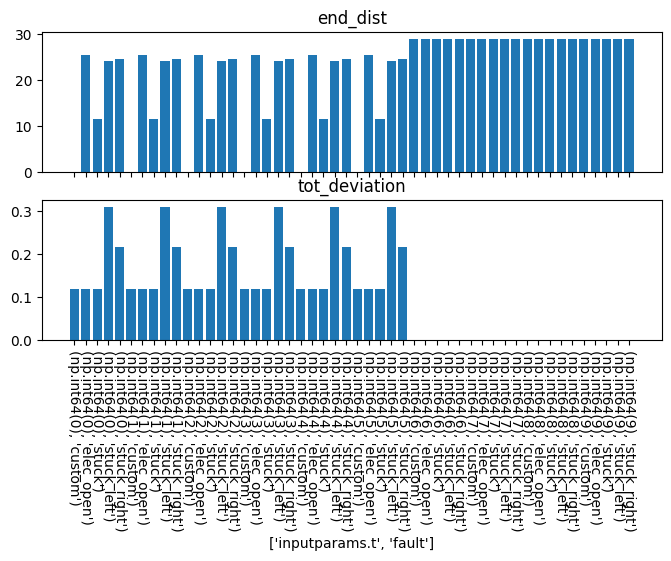

In [46]:
fig, axs = nc.as_plots('end_dist', 'tot_deviation', figsize = (8, 4))